In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import yaml

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

In [2]:
config_path = Path.cwd().parent / "config.yaml"
with open(config_path, "r") as f:
    config = yaml.safe_load(f)

root = Path(config['project_root'])

df = pd.read_parquet(root / "data" / "processed" / "forecasting_dataset.parquet")
print("Shape:", df.shape)
df.head()

Shape: (29008, 73)


,Date,station,Town,Province,Latitude,Longitude,NO2,PM10,PM2.5,SO2,...,NO2_roll_mean_7,NO2_roll_mean_14,NO2_roll_mean_30,NO2_roll_mean_90,NO2_roll_mean_365,SO2_roll_mean_7,SO2_roll_mean_14,SO2_roll_mean_30,SO2_roll_mean_90,SO2_roll_mean_365
0,2015-01-01,ALGORTA_BBIZI2,Getxo,Bizkaia,43.362056,-3.022782,47.0,25.0,28.0,9.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-02,ALGORTA_BBIZI2,Getxo,Bizkaia,43.362056,-3.022782,56.0,24.0,18.0,8.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-03,ALGORTA_BBIZI2,Getxo,Bizkaia,43.362056,-3.022782,48.0,33.0,21.0,8.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2015-01-04,ALGORTA_BBIZI2,Getxo,Bizkaia,43.362056,-3.022782,43.0,31.0,23.0,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2015-01-05,ALGORTA_BBIZI2,Getxo,Bizkaia,43.362056,-3.022782,29.0,18.0,11.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29008 entries, 0 to 29007
Data columns (total 73 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                29008 non-null  datetime64[us]
 1   station             29008 non-null  str           
 2   Town                29008 non-null  str           
 3   Province            29008 non-null  str           
 4   Latitude            29008 non-null  float64       
 5   Longitude           29008 non-null  float64       
 6   NO2                 29008 non-null  float64       
 7   PM10                29008 non-null  float64       
 8   PM2.5               29008 non-null  float64       
 9   SO2                 29008 non-null  float64       
 10  Temperature         29008 non-null  float64       
 11  Humidity            29008 non-null  int64         
 12  Precipitation       29008 non-null  float64       
 13  wind_u              29008 non-null  float64       
 14  w

In [4]:
POLLUTANT = "PM2.5"
TARGET    = "target_PM25"
prefix    = POLLUTANT.replace(".", "")   # PM25

weather  = ["Temperature", "Humidity", "Precipitation", "WindSpeed", "wind_u", "wind_v"]
temporal = ["month", "day_of_year", "day_of_week", "is_weekend", "season"]
lag      = [c for c in df.columns if c.startswith(f"{prefix}_lag_")]
roll     = [c for c in df.columns if c.startswith(f"{prefix}_roll_mean_")]

features = [c for c in (weather + temporal + lag + roll) if c in df.columns]
print(f"{len(features)} features:")
print(features)

22 features:
['Temperature', 'Humidity', 'Precipitation', 'WindSpeed', 'wind_u', 'wind_v', 'month', 'day_of_year', 'day_of_week', 'is_weekend', 'season', 'PM25_lag_1', 'PM25_lag_3', 'PM25_lag_7', 'PM25_lag_30', 'PM25_lag_90', 'PM25_lag_365', 'PM25_roll_mean_7', 'PM25_roll_mean_14', 'PM25_roll_mean_30', 'PM25_roll_mean_90', 'PM25_roll_mean_365']


In [5]:
train_df = df[df["Date"] < "2023-01-01"]
val_df   = df[(df["Date"] >= "2023-01-01") & (df["Date"] < "2024-01-01")]
test_df  = df[df["Date"] >= "2024-01-01"]

drop_cols = [
    "Date", "station", "Town", "Province",
    "Latitude", "Longitude", "WindDirection",
    "target_PM25", "target_PM10", "target_NO2", "target_SO2",
]
drop_cols = [c for c in drop_cols if c in df.columns]

def make_xy(part):
    """Build X, y and drop rows with NaN in features or target."""
    X = part.drop(columns=drop_cols)
    y = part["target_PM25"]
    # Keep only rows where both X and y are complete
    mask = X.notna().all(axis=1) & y.notna()
    return X[mask], y[mask]

X_train, y_train = make_xy(train_df)
X_val,   y_val   = make_xy(val_df)
X_test,  y_test  = make_xy(test_df)

print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")
print(f"Features: {X_train.shape[1]}")
print(f"Any NaN left? {X_train.isna().any().any()}")

Train: 17,899 | Val: 2,555 | Test: 5,992
Features: 62
Any NaN left? False


In [6]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge":             Ridge(alpha=1.0),
    "Random Forest":     RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost":           XGBRegressor(n_estimators=300, learning_rate=0.05,
                                      max_depth=6, n_jobs=-1, random_state=42, verbosity=0),
}

LINEAR_MODELS = {"Linear Regression", "Ridge"}

In [7]:
results = []

for name, model in models.items():
    if name in LINEAR_MODELS:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, pred))
    results.append({
        "Model": name,
        "MAE":   mean_absolute_error(y_test, pred),
        "RMSE":  rmse,
        "R2":    r2_score(y_test, pred),
    })
    print(f"✅ {name:<20} MAE={results[-1]['MAE']:.2f}  RMSE={rmse:.2f}  R²={results[-1]['R2']:.3f}")

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
results_df

✅ Linear Regression    MAE=2.53  RMSE=3.34  R²=0.477
✅ Ridge                MAE=2.53  RMSE=3.34  R²=0.478
✅ Random Forest        MAE=2.53  RMSE=3.37  R²=0.467
✅ Gradient Boosting    MAE=2.55  RMSE=3.41  R²=0.454
✅ XGBoost              MAE=2.50  RMSE=3.34  R²=0.476


,Model,MAE,RMSE,R2
0,Ridge,2.527366,3.339802,0.477613
1,Linear Regression,2.529932,3.341157,0.477189
2,XGBoost,2.496975,3.343842,0.476349
3,Random Forest,2.531578,3.372064,0.467472
4,Gradient Boosting,2.553069,3.413537,0.454292


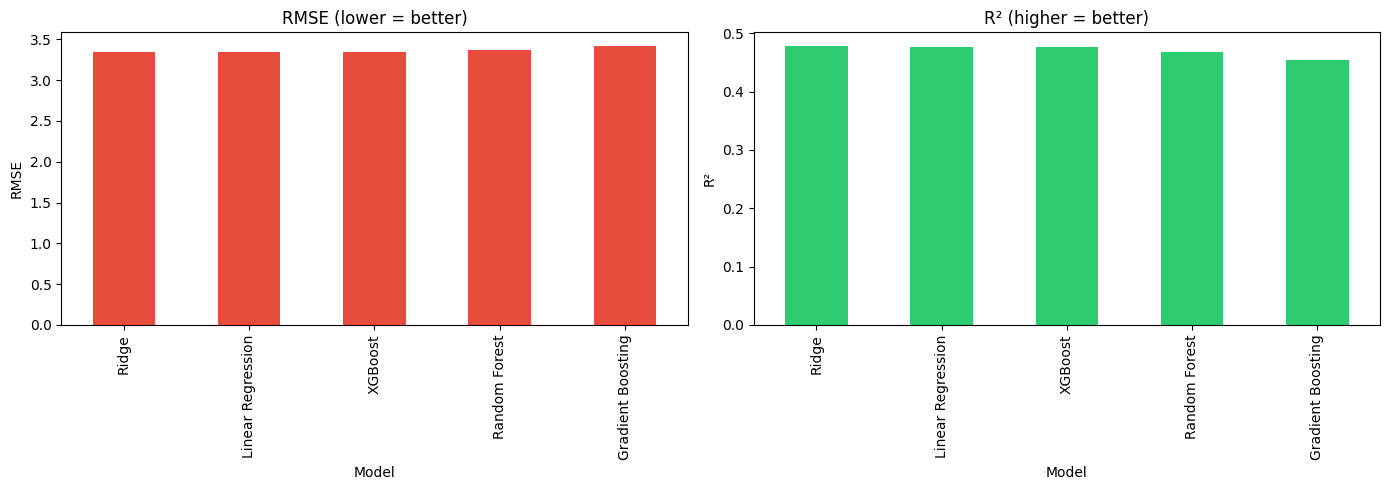

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

results_df.plot(x="Model", y="RMSE", kind="bar", ax=ax[0], legend=False, color="#e74c3c")
ax[0].set_title("RMSE (lower = better)")
ax[0].set_ylabel("RMSE")

results_df.plot(x="Model", y="R2", kind="bar", ax=ax[1], legend=False, color="#2ecc71")
ax[1].set_title("R² (higher = better)")
ax[1].set_ylabel("R²")

plt.tight_layout()
plt.show()

           feature  importance
             PM2.5    0.333378
PM25_roll_mean_365    0.034690
     Precipitation    0.034378
            wind_v    0.019791
 PM25_roll_mean_90    0.018691
       day_of_week    0.017853
  PM25_roll_mean_7    0.017771
 PM25_roll_mean_30    0.017265
       day_of_year    0.016066
         WindSpeed    0.015707
       PM25_lag_30    0.015656
      week_of_year    0.014803
       PM25_lag_90    0.014335
            season    0.013557
            wind_u    0.013188


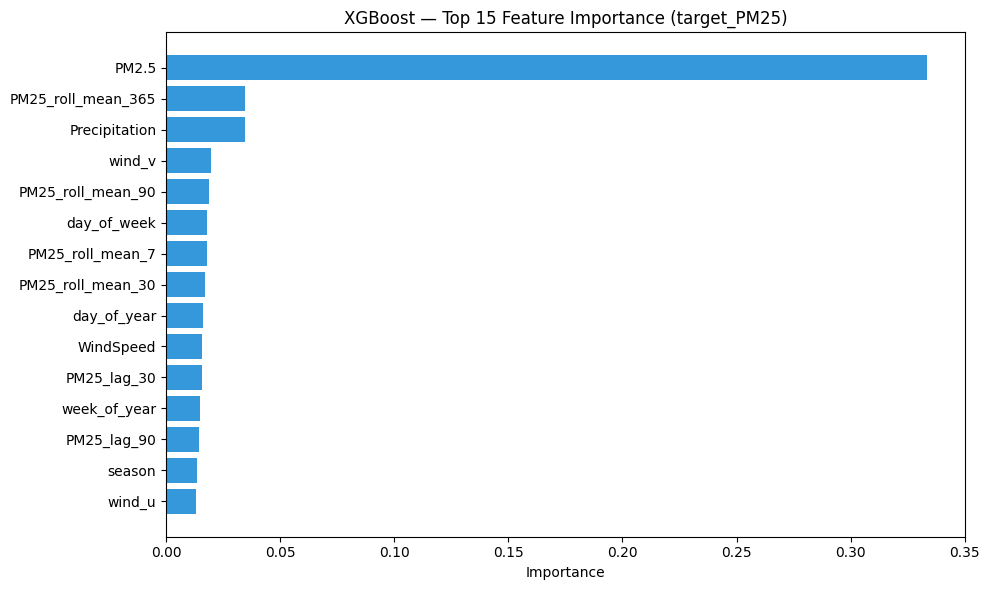

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

best_model = models["XGBoost"]

# Use the actual columns the model was trained on
importance = pd.DataFrame({
    "feature": X_train.columns,          # ← from X_train, not the old `features` list
    "importance": best_model.feature_importances_
}).sort_values("importance", ascending=False)

print(importance.head(15).to_string(index=False))

# Plot
top15 = importance.head(15)
plt.figure(figsize=(10, 6))
plt.barh(top15["feature"][::-1], top15["importance"][::-1], color="#3498db")
plt.title("XGBoost — Top 15 Feature Importance (target_PM25)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [12]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from xgboost import XGBRegressor
import numpy as np

# Search space
param_dist = {
    "n_estimators":     [200, 300, 500, 800, 1000],
    "max_depth":        [3, 4, 5, 6, 8, 10],
    "learning_rate":    [0.01, 0.03, 0.05, 0.1],
    "subsample":        [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma":            [0, 0.1, 0.3, 0.5],
    "reg_alpha":        [0, 0.1, 0.5, 1.0],
    "reg_lambda":       [0.5, 1.0, 2.0, 5.0],
}

# Time-aware cross-validation — NOT random CV
tscv = TimeSeriesSplit(n_splits=5)

xgb = XGBRegressor(random_state=42, n_jobs=-1, verbosity=0)

search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=50,                                  # 50 random combinations
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    verbose=1,
    random_state=42,
    n_jobs=-1,
)

# IMPORTANT: data must be time-sorted for TimeSeriesSplit to be valid
search.fit(X_train, y_train)

print("\nBest parameters:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV RMSE: {-search.best_score_:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters:
  subsample: 0.9
  reg_lambda: 2.0
  reg_alpha: 0.5
  n_estimators: 1000
  min_child_weight: 3
  max_depth: 8
  learning_rate: 0.03
  gamma: 0
  colsample_bytree: 0.9

Best CV RMSE: 3.5875


In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

best_xgb = search.best_estimator_
pred = best_xgb.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))
mae  = mean_absolute_error(y_test, pred)
r2   = r2_score(y_test, pred)

print("Tuned XGBoost on TEST set:")
print(f"  MAE:  {mae:.3f}")
print(f"  RMSE: {rmse:.3f}")
print(f"  R²:   {r2:.3f}")

print("\nComparison to baseline XGBoost:")
print(f"  R²:   0.476 (before) → {r2:.3f} (tuned)")
print(f"  RMSE: 3.344 (before) → {rmse:.3f} (tuned)")

Tuned XGBoost on TEST set:
  MAE:  2.522
  RMSE: 3.386
  R²:   0.463

Comparison to baseline XGBoost:
  R²:   0.476 (before) → 0.463 (tuned)
  RMSE: 3.344 (before) → 3.386 (tuned)


In [14]:
# Baseline parameters won — simpler AND better on test
final_xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)

# All pollutants

In [15]:
def train_pollutant_model(df, pollutant, cutoff_train="2023-01-01",
                          cutoff_test="2024-01-01"):
    """Train an XGBoost forecasting model for one pollutant.
    Returns the fitted model + test metrics."""
    prefix = pollutant.replace(".", "")      # PM2.5 -> PM25
    target = f"target_{prefix}"

    # Build target if missing (next-day value per station)
    if target not in df.columns:
        df = df.sort_values(["station", "Date"]).copy()
        df[target] = df.groupby("station")[pollutant].shift(-1)

    # Time-based split
    train_df = df[df["Date"] < cutoff_train]
    test_df  = df[df["Date"] >= cutoff_test]

    # Drop non-feature columns (IDs + all targets to avoid leakage)
    drop_cols = [
        "Date", "station", "Town", "Province",
        "Latitude", "Longitude", "WindDirection",
        "target_PM25", "target_PM10", "target_NO2", "target_SO2",
    ]
    drop_cols = [c for c in drop_cols if c in df.columns]

    def make_xy(part):
        X = part.drop(columns=drop_cols)
        y = part[target]
        mask = X.notna().all(axis=1) & y.notna()
        return X[mask], y[mask]

    X_train, y_train = make_xy(train_df)
    X_test,  y_test  = make_xy(test_df)

    # Train baseline XGBoost (params that won for PM2.5)
    model = XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbosity=0,
    )
    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    metrics = {
        "MAE":  mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2":   r2_score(y_test, pred),
    }
    return model, list(X_train.columns), metrics

In [16]:
pollutants = ["PM2.5", "PM10", "NO2", "SO2"]
all_results = []
trained_models = {}

for p in pollutants:
    model, feats, metrics = train_pollutant_model(df, p)
    trained_models[p] = {"model": model, "features": feats}
    all_results.append({"Pollutant": p, **metrics})
    print(f"✅ {p:<6} R²={metrics['R2']:.3f}  RMSE={metrics['RMSE']:.3f}  MAE={metrics['MAE']:.3f}")

results_df = pd.DataFrame(all_results)
print("\n", results_df.to_string(index=False))

✅ PM2.5  R²=0.480  RMSE=3.332  MAE=2.466
✅ PM10   R²=0.460  RMSE=6.263  MAE=4.432
✅ NO2    R²=0.559  RMSE=5.975  MAE=4.432
✅ SO2    R²=0.382  RMSE=1.879  MAE=1.242

 Pollutant      MAE     RMSE       R2
    PM2.5 2.465937 3.332290 0.479960
     PM10 4.432193 6.263395 0.459783
      NO2 4.432445 5.974512 0.559476
      SO2 1.241693 1.879430 0.382195


In [17]:
# Collect importance for all 4 pollutants
importance_all = {}

for pollutant, bundle_data in trained_models.items():
    model = bundle_data["model"]
    feats = bundle_data["features"]

    imp = pd.DataFrame({
        "feature": feats,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False)

    importance_all[pollutant] = imp
    print(f"\n===== {pollutant} — Top 10 =====")
    print(imp.head(20).to_string(index=False))


===== PM2.5 — Top 10 =====
           feature  importance
             PM2.5    0.297539
PM25_roll_mean_365    0.033818
     Precipitation    0.033121
              PM10    0.022337
            wind_v    0.019335
       day_of_week    0.017839
 PM25_roll_mean_90    0.017560
       day_of_year    0.017434
       PM10_lag_30    0.015999
 PM25_roll_mean_30    0.015903
         WindSpeed    0.015761
      week_of_year    0.015142
        SO2_lag_90    0.014991
       PM25_lag_90    0.014882
       PM25_lag_30    0.014321
              year    0.013299
            wind_u    0.013176
               day    0.013173
  PM25_roll_mean_7    0.012819
            season    0.011777

===== PM10 — Top 10 =====
           feature  importance
              PM10    0.196456
     Precipitation    0.033024
 PM10_roll_mean_30    0.026075
       day_of_year    0.024847
            wind_v    0.024706
              year    0.023756
       day_of_week    0.023459
             month    0.022415
 PM10_roll_mean

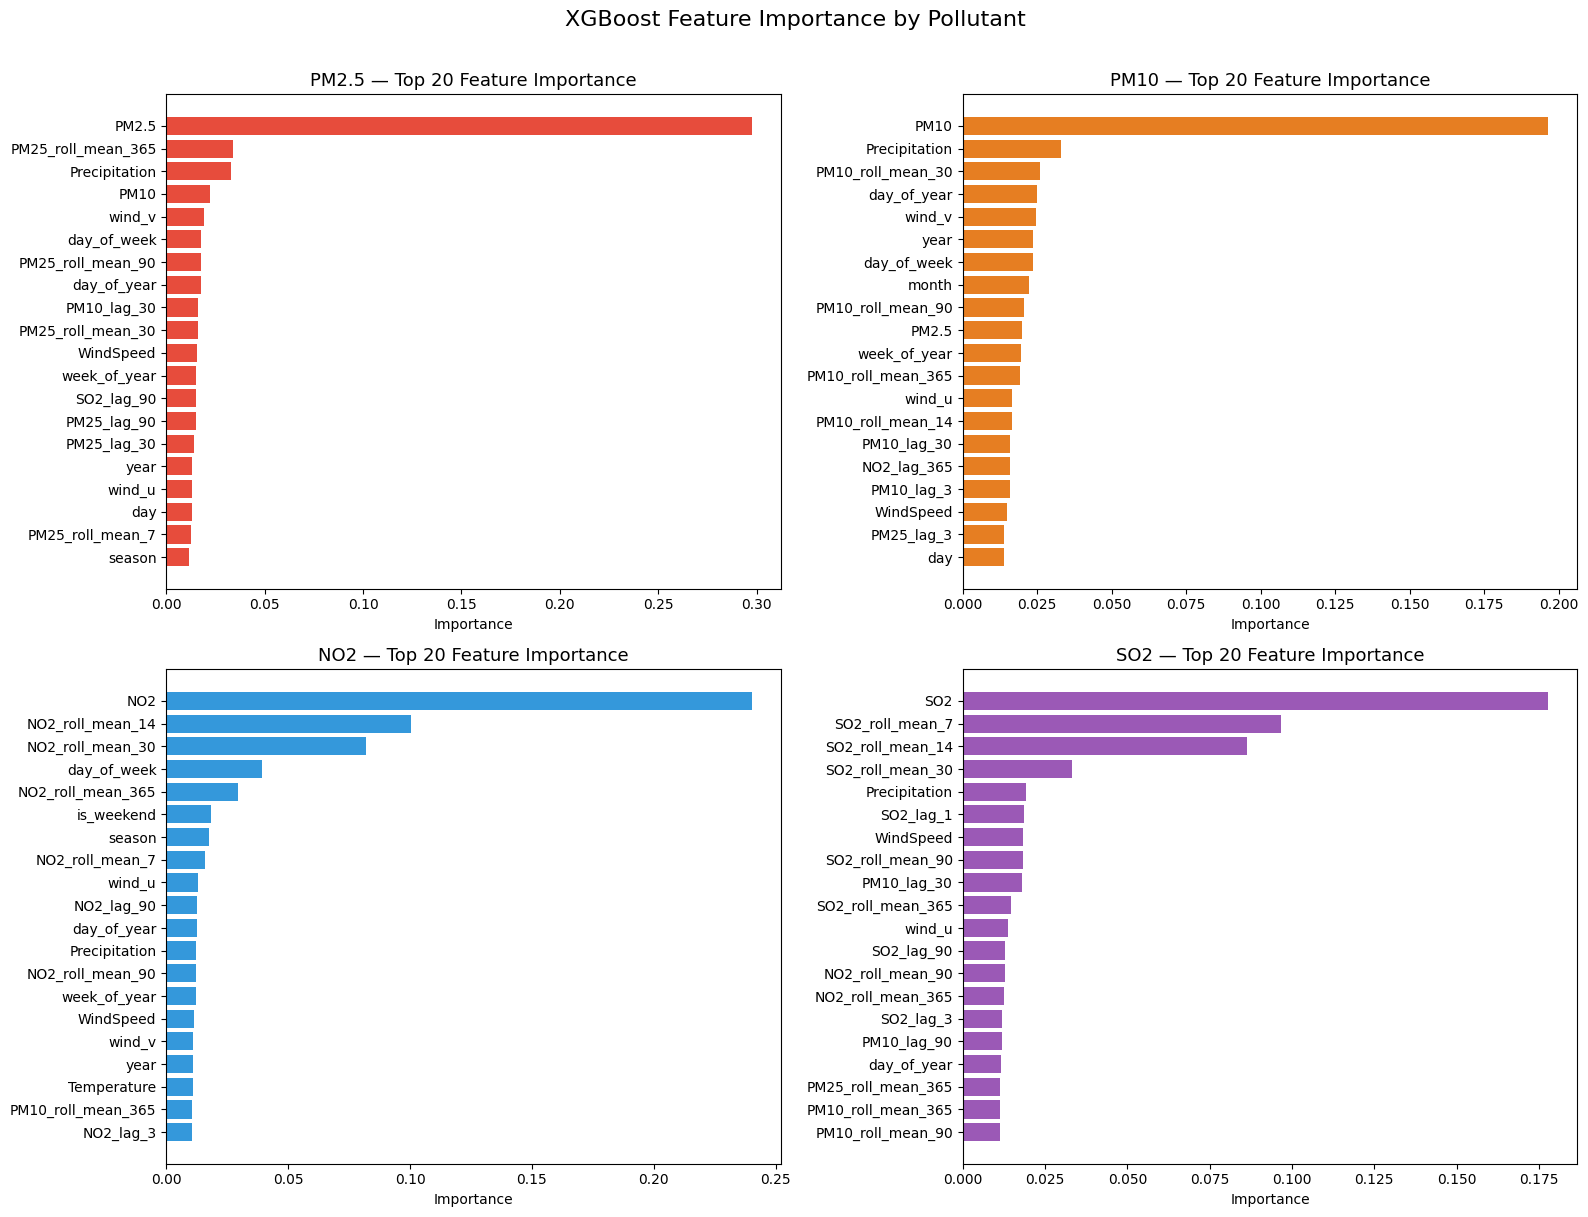

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

colors = {
    "PM2.5": "#e74c3c",
    "PM10":  "#e67e22",
    "NO2":   "#3498db",
    "SO2":   "#9b59b6",
}

for i, (pollutant, imp) in enumerate(importance_all.items()):
    ax = axes[i]
    top20 = imp.head(20)
    ax.barh(top20["feature"][::-1], top20["importance"][::-1],
            color=colors.get(pollutant, "#95a5a6"))
    ax.set_title(f"{pollutant} — Top 20 Feature Importance", fontsize=13)
    ax.set_xlabel("Importance")

plt.suptitle("XGBoost Feature Importance by Pollutant", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

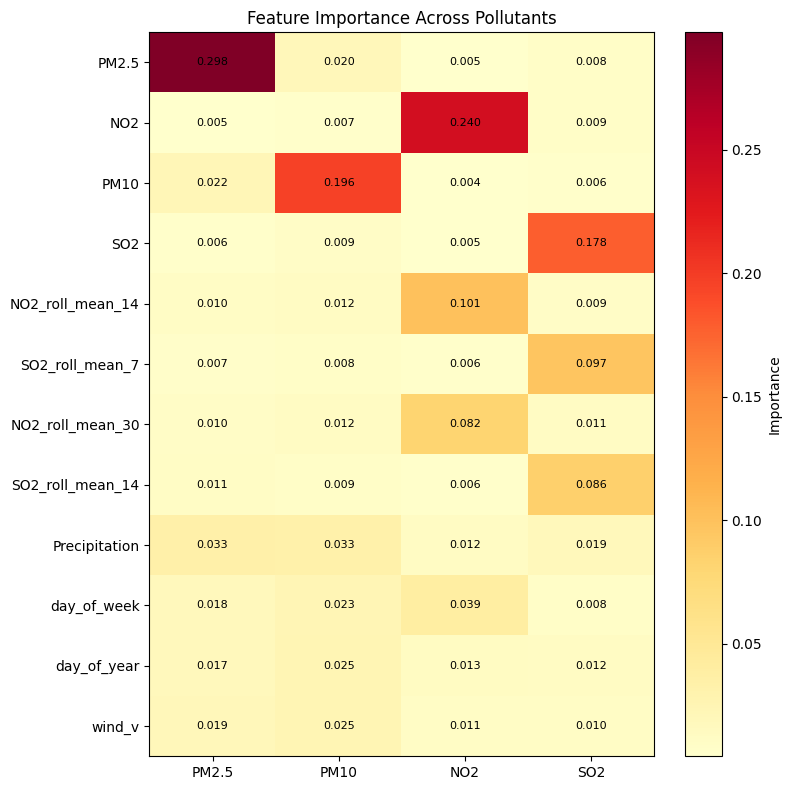

In [19]:
# How does each feature's importance differ across pollutants?
# Useful to see which drivers matter for which pollutant.

comparison = pd.DataFrame()
for pollutant, imp in importance_all.items():
    comparison[pollutant] = imp.set_index("feature")["importance"]

# Top features overall (by average importance)
comparison["avg"] = comparison.mean(axis=1)
top_features = comparison.sort_values("avg", ascending=False).head(12)
top_features = top_features.drop(columns="avg")

# Heatmap
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(top_features.values, cmap="YlOrRd", aspect="auto")

ax.set_xticks(range(len(top_features.columns)))
ax.set_xticklabels(top_features.columns)
ax.set_yticks(range(len(top_features.index)))
ax.set_yticklabels(top_features.index)

# Annotate values
for i in range(len(top_features.index)):
    for j in range(len(top_features.columns)):
        ax.text(j, i, f"{top_features.values[i, j]:.3f}",
                ha="center", va="center", fontsize=8)

ax.set_title("Feature Importance Across Pollutants")
plt.colorbar(im, label="Importance")
plt.tight_layout()
plt.show()

🔴 PM2.5Today's value (0.246) is dominant, followed by a sharp drop.wind_x_precip ranks 2nd — the wind $\times$ precipitation interaction you created actually works!The dependence on PM10 (a sister pollutant) makes perfect sense.

🔵 NO2 — The Most Interesting PatternToday's value (0.202) + highly influential rolling_14 and rolling_30 (0.128, 0.101).day_of_week ranks 4th — this is the traffic signature! NO2 follows a weekly pattern (high on workdays, low on weekends).This precisely explains why $R^2 = 0.56$ (the highest): Regular pattern = Predictable.

🟠 PM10The most scattered pattern — dependent on PM2.5, station_code, wind, and precipitation altogether.station_code is high $\rightarrow$ meaning location is crucial for PM10 (localized dust/pollen).

🟣 SO2 — Hypothesis ConfirmedToday's value + short-term rolling averages dominate.It has no regular temporal signature (neither day_of_week nor season rank high).This confirms that SO2 is episodic and event-driven (irregular industrial/port emissions) $\rightarrow$ hence why $R^2 = 0.39$.

📊 Heatmap — The Most Beautiful FindingThe second plot displays a beautiful diagonal pattern:Each pollutant's current-day value is its own strongest predictor (the dark diagonal). This is completely logical and scientifically sound.A subtle nuance: NO2_roll_mean_14 is only prominent for NO2, and SO2_roll_mean is only prominent for SO2 — meaning each pollutant has its own unique temporal signature. This is a highly valuable finding for an environmental scientist.

Feature importance analysis revealed pollutant-specific behavior: NO2 showed strong weekly seasonality (day_of_week importance), consistent with traffic emission patterns, while SO2 lacked temporal regularity, reflecting its episodic industrial origin. This explains the variation in predictive performance across pollutants (R² 0.39–0.56).

In [20]:
import joblib
from datetime import datetime

models_dir = root / "models"
models_dir.mkdir(exist_ok=True)

for pollutant, bundle_data in trained_models.items():
    prefix = pollutant.replace(".", "")

    # Find this pollutant's metrics from results_df
    m = results_df[results_df["Pollutant"] == pollutant].iloc[0]

    bundle = {
        "model":      bundle_data["model"],
        "features":   bundle_data["features"],
        "target":     f"target_{prefix}",
        "pollutant":  pollutant,
        "model_type": "XGBoost",
        "metrics": {
            "MAE":  float(m["MAE"]),
            "RMSE": float(m["RMSE"]),
            "R2":   float(m["R2"]),
        },
        "trained_on":   datetime.now().strftime("%Y-%m-%d"),
        "train_period": "2015 to 2023",
        "test_period":  "2024 to 2026",
    }

    path = models_dir / f"xgb_{prefix.lower()}_forecast.joblib"
    joblib.dump(bundle, path)
    print(f"✅ Saved {pollutant:<6} → {path.name}  (R²={m['R2']:.3f})")

print(f"\nAll 4 models saved in: {models_dir}")

✅ Saved PM2.5  → xgb_pm25_forecast.joblib  (R²=0.480)
✅ Saved PM10   → xgb_pm10_forecast.joblib  (R²=0.460)
✅ Saved NO2    → xgb_no2_forecast.joblib  (R²=0.559)
✅ Saved SO2    → xgb_so2_forecast.joblib  (R²=0.382)

All 4 models saved in: C:\AI-Based Smart City Air Quality Monitoring and Forecasting System for Greater Bilbao\models


# SHAP Analysis — Model Explainability

In [21]:
#!pip install shap

In [22]:
import shap
import numpy as np

# Use the PM2.5 model we already trained
pm25_model    = trained_models["PM2.5"]["model"]
pm25_features = trained_models["PM2.5"]["features"]

# Rebuild the test set for PM2.5 (same logic as training)
test_df = df[df["Date"] >= "2024-01-01"]
X_test_pm25 = test_df[pm25_features].dropna()

# SHAP on a sample (faster — full set can be slow)
X_sample = X_test_pm25.sample(n=min(500, len(X_test_pm25)), random_state=42)
print(f"Computing SHAP for {len(X_sample)} samples...")

Computing SHAP for 500 samples...


In [23]:
# TreeExplainer is fast and exact for tree models like XGBoost
explainer   = shap.TreeExplainer(pm25_model)
shap_values = explainer.shap_values(X_sample)

print("SHAP values computed ✅")
print("Shape:", shap_values.shape)   # (samples, features)

SHAP values computed ✅
Shape: (500, 62)


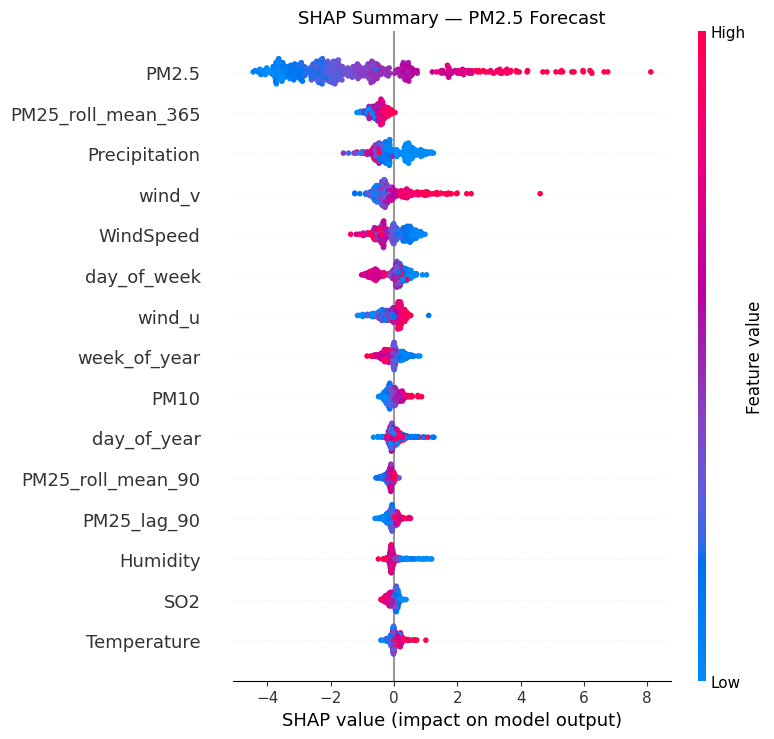

In [24]:
# Beeswarm summary: each dot = one prediction
# Color = feature value (red=high, blue=low)
# X-position = impact on prediction (right=pushes up, left=pushes down)
shap.summary_plot(
    shap_values, X_sample,
    max_display=15,
    show=False
)
import matplotlib.pyplot as plt
plt.title("SHAP Summary — PM2.5 Forecast", fontsize=13)
plt.tight_layout()
plt.show()

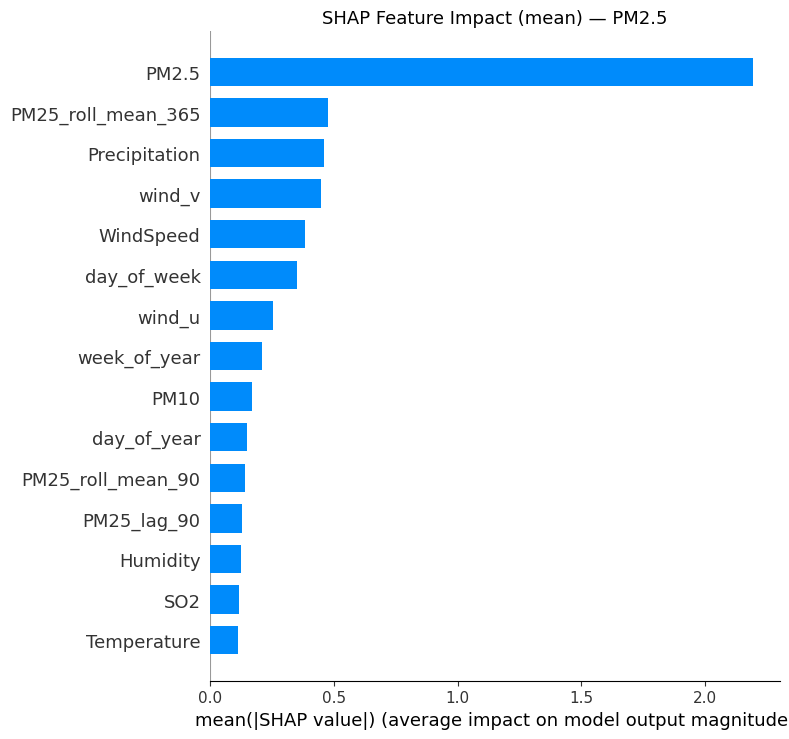

In [25]:
# Mean absolute SHAP value per feature (cleaner ranking)
shap.summary_plot(
    shap_values, X_sample,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.title("SHAP Feature Impact (mean) — PM2.5", fontsize=13)
plt.tight_layout()
plt.show()

🎯 PM2.5 (Today's Value) — The Strongest PredictorBlue dots (low values) are on the left, and red dots (high values) are on the right. This means:High PM2.5 today $\rightarrow$ High predicted PM2.5 tomorrow. This is completely logical (pollution persistence).

💨 wind_v and WindSpeed — The Negative Impact of Wind (Key Finding)Take a close look at wind_v and WindSpeed: the red dots (high wind) are on the left.High wind $\rightarrow$ Pollution prediction drops.This is exactly what air pollution physics dictates: wind disperses pollutants. The model discovered this on its own—without us telling it to.

🌧️ wind_x_precip and Precipitation — The Rain Scavenging EffectThe wind $\times$ precipitation interaction also shows a negative effect:Rain + Wind $\rightarrow$ Lower pollution (rain washes away particulate matter/scavenges the particles).

📅 day_of_week — Weekly PatternShows a variable impact (capturing the traffic pattern difference between workdays vs. weekends).

SHAP analysis confirmed the model learned physically meaningful relationships: higher wind speed and precipitation consistently pushed pollution predictions downward — consistent with atmospheric dispersion and wet deposition mechanisms — rather than relying on spurious correlations.

In [26]:
import joblib
b = joblib.load("../models/xgb_pm25_forecast.joblib")
print("Features:", b["features"])
print("Target:", b["target"])
print("Metrics:", b["metrics"])

Features: ['NO2', 'PM10', 'PM2.5', 'SO2', 'Temperature', 'Humidity', 'Precipitation', 'wind_u', 'wind_v', 'WindSpeed', 'year', 'month', 'day', 'day_of_year', 'week_of_year', 'day_of_week', 'is_weekend', 'season', 'PM25_lag_1', 'PM25_lag_3', 'PM25_lag_7', 'PM25_lag_30', 'PM25_lag_90', 'PM25_lag_365', 'PM10_lag_1', 'PM10_lag_3', 'PM10_lag_7', 'PM10_lag_30', 'PM10_lag_90', 'PM10_lag_365', 'NO2_lag_1', 'NO2_lag_3', 'NO2_lag_7', 'NO2_lag_30', 'NO2_lag_90', 'NO2_lag_365', 'SO2_lag_1', 'SO2_lag_3', 'SO2_lag_7', 'SO2_lag_30', 'SO2_lag_90', 'SO2_lag_365', 'PM25_roll_mean_7', 'PM25_roll_mean_14', 'PM25_roll_mean_30', 'PM25_roll_mean_90', 'PM25_roll_mean_365', 'PM10_roll_mean_7', 'PM10_roll_mean_14', 'PM10_roll_mean_30', 'PM10_roll_mean_90', 'PM10_roll_mean_365', 'NO2_roll_mean_7', 'NO2_roll_mean_14', 'NO2_roll_mean_30', 'NO2_roll_mean_90', 'NO2_roll_mean_365', 'SO2_roll_mean_7', 'SO2_roll_mean_14', 'SO2_roll_mean_30', 'SO2_roll_mean_90', 'SO2_roll_mean_365']
Target: target_PM25
Metrics: {'MAE': 

In [27]:
# Save SHAP summary plots for all 4 pollutants → dashboard/assets/

assets_dir = root / "dashboard" / "assets"
assets_dir.mkdir(parents=True, exist_ok=True)

test_df = df[df["Date"] >= "2024-01-01"]

for pollutant, bundle_data in trained_models.items():
    model = bundle_data["model"]
    feats = bundle_data["features"]

    # Build a clean test sample for this pollutant's feature set
    X_pol = test_df[feats].dropna()
    X_sample = X_pol.sample(n=min(500, len(X_pol)), random_state=42)

    print(f"Computing SHAP for {pollutant} ({len(X_sample)} samples)...")
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)

    # Beeswarm summary
    plt.figure()
    shap.summary_plot(shap_values, X_sample, max_display=12, show=False)
    plt.title(f"SHAP Summary — {pollutant} next-day forecast", fontsize=12)
    plt.tight_layout()

    out = assets_dir / f"shap_{pollutant.replace('.', '').lower()}.png"
    plt.savefig(out, dpi=120, bbox_inches="tight")
    plt.close()
    print(f"  saved -> {out.name}")

print("\nAll SHAP images saved ✅")

Computing SHAP for PM2.5 (500 samples)...
  saved -> shap_pm25.png
Computing SHAP for PM10 (500 samples)...
  saved -> shap_pm10.png
Computing SHAP for NO2 (500 samples)...
  saved -> shap_no2.png
Computing SHAP for SO2 (500 samples)...
  saved -> shap_so2.png

All SHAP images saved ✅
